# 02 – Exploratory Data Analysis

**Project:** AI-Powered Project Planning & Risk Forecasting Platform


This notebook performs **Exploratory Data Analysis (EDA)** to understand patterns in historical project data.

The goal of EDA is to move beyond basic data inspection and identify patterns that are relevant for:

- identifying project delays
- understanding project risk levels
- supporting forecasting assumptions  
- informing simulation design  

In this notebook, to explore:

1. The overall structure of the historical project data  
2. The distribution of target variables  
3. Relationships between project characteristics and delay outcomes  
4. Patterns that may support risk prediction models  

This notebook does NOT involve machine learning modeling. Instead, it focuses on **understanding the data before modeling and simulation**.

The insights discovered here will guide **feature engineering and model development** in the next notebook. 

## Dataset Scope Clarification

Although multiple datasets exist in the project, this notebook focuses on:

- **project_portfolio_history.csv** → used for exploratory analysis  

The monitoring dataset is used later for performance tracking and is not part of this exploratory analysis.

This separation ensures:
- clarity of purpose
- no data leakage between modeling stages

In [16]:
# Core libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Initial Data Inspection

A sample of the dataset is being inspected to:

- verify that data has been loaded correctly  
- understand the structure of variables  
- identify key project attributes  

This step provides a first understanding of:
- project characteristics  
- planning vs actual outcomes  
- potential delay indicators  

This dataset contains project-level features such as:

- complexity
- duration
- budget performance
- vendor involvement
- stakeholder alignment
- outcome risk level

This is the main dataset used for EDA and model development.

### Loading Dataset

In [17]:
project_df = pd.read_csv("../data/project_portfolio_history.csv")

project_df.head()

,Project_ID,Portfolio_Segment,Region,Delivery_Model,Planning_Mode,Complexity_Score,Planned_Duration_Days,Actual_Duration_Days,Delay_Days,Delay_Flag,Planned_Budget_USD,Actual_Budget_USD,Budget_Overrun_Pct,Team_Size,Critical_Path_Task_Count,Vendor_Count,Change_Order_Count,Resource_Buffer_Pct,Weather_Risk_Index,Procurement_Risk_Index,Stakeholder_Alignment_Score,Requirements_Volatility_Score,Forecast_Error_Days,Outcome_Risk_Level
0,P001,Public Sector,South,Design-Build,Spreadsheet,69,301,296,-5,On Time,"5,346,606.61","5,749,331.62",7.53,24,12,11,4,8.30,5.00,35.10,68.10,31.70,3,Low
1,P002,Infrastructure,Central,Design-Build,Spreadsheet,63,266,267,1,Delayed,"5,160,994.06","5,788,216.98",12.15,27,11,8,7,12.00,10.30,7.00,60.20,56.60,1,Low
2,P003,Commercial,North,Agile Hybrid,Spreadsheet,68,304,304,0,On Time,"4,543,371.36","5,210,515.82",14.68,18,14,10,4,4.40,40.90,72.50,52.90,43.30,2,Medium
3,P004,Commercial,West,EPC,Spreadsheet,50,244,245,1,Delayed,"3,808,792.38","4,328,783.59",13.65,19,10,9,2,11.20,22.40,52.30,57.70,35.60,1,Low
4,P005,Industrial,South,Design-Build,Manual,61,292,299,7,Delayed,"4,317,590.16","4,697,882.16",8.81,20,10,5,7,2.40,35.20,25.80,53.50,44.20,11,Low


**Key Insight**

- The dataset contains historical project-level information including schedule, cost, and risk indicators.
- It serves as the foundation for understanding patterns related to project delays and risk outcomes.
- This dataset will be used to identify key drivers of risk and inform downstream modeling decisions.

## Training Dataset Description

The dataset `project_portfolio_history.csv` contains historical project portfolio data used to support the development of risk forecasting approaches.

Each record represents a completed project and includes information about project characteristics such as complexity, budget, duration, team size, vendor involvement, and various operational risk indicators.

The dataset also includes outcome variables such as delay days, budget overruns, and the final project risk level.

This historical data allows the model to learn relationships between project characteristics and delivery outcomes, enabling the prediction of project risk levels for future projects.

The dataset will be used for:
- exploratory data analysis (EDA)
- feature understanding
inform the next phase of predictive modeling
- identifying key factors associated with project delivery risk

## Dataset Shape

Before exploring individual variables, the size of the dataset is checked.

This helps to understand:

- how many project records are available
- how many variables can be analyzed

In [18]:
print("Rows:", project_df.shape[0])
print("Columns:", project_df.shape[1])

Rows: 360
Columns: 24


## Key Outcome Variables

The following are two important outcome variables that describe project performance:

##### 1. `Delay_Flag`
Indicates whether a project finished **on time** or was **delayed**.

##### 2. `Outcome_Risk_Level`
Represents the project’s overall **risk classification**.

These variables are important because they connect directly to the business problem:

- delayed projects reduce planning reliability  
- higher-risk projects require better early detection  

In this notebook, these variables are used to **understand project outcomes and patterns**, not for predictive modeling.

## Distribution of Project Delays

First, the distribution of the `Delay_Flag` variable are examined.

This helps answer a basic but important question:

**How common are project delays in the historical data?**

Understanding this distribution provides context for later modeling and shows whether delays are a widespread planning issue.

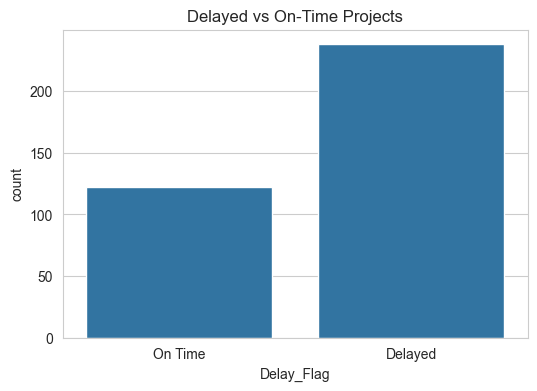

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Delay_Flag",
    data=project_df
)

plt.title("Delayed vs On-Time Projects")
plt.show()

**Key Insight**

- The chart compares the number of delayed projects with projects delivered on time.
- Delayed projects appear frequently in the dataset, indicating that schedule slippage is a meaningful issue rather than a rare exception.
- This supports the relevance of delay-related variables for downstream forecasting and risk analysis.

## Distribution of Risk Levels

Next, the `Outcome_Risk_Level` variable is inspected.

This helps to understand how projects are distributed across:

- Low risk
- Medium risk
- High risk

This distribution is useful because it indicates the balance of the target classes that will later be used in machine learning models.

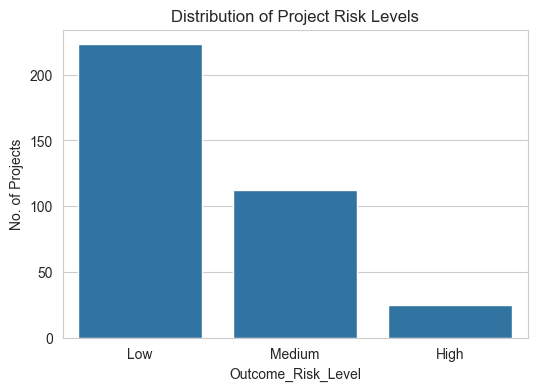

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Outcome_Risk_Level",
    data=project_df,
    order=["Low","Medium","High"]
)

plt.title("Distribution of Project Risk Levels")
plt.xlabel("Outcome_Risk_Level")
plt.ylabel("No. of Projects")
plt.show()

**Key Insight**

- Low Risk projects dominate the dataset, followed by Medium Risk, with High Risk projects appearing far less often.
- This indicates a clear class imbalance, especially for the High Risk category.
- Such imbalance can bias predictive models toward majority classes and reduce performance on the most critical high-risk cases.
- This justifies the later use of Macro F1 and imbalance-aware modeling approaches.

## Project Complexity Distribution

Project complexity is one of the most relevant explanatory variables in the dataset.

Its distribution is examined to understand:

- whether projects tend to cluster around certain complexity levels
- whether the data contains a broad range of low- to high-complexity projects

This is important because complexity is expected to influence both project risk and delivery performance.

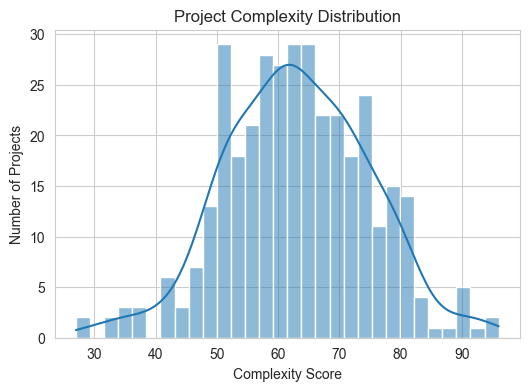

In [21]:
plt.figure(figsize=(6,4))

sns.histplot(
    project_df["Complexity_Score"],
    bins=30,
    kde=True
)

plt.title("Project Complexity Distribution")
plt.xlabel("Complexity Score")
plt.ylabel("Number of Projects")
plt.show()

**Key Insight**

- The chart shows how project complexity scores are distributed across the portfolio.
- Most projects are concentrated in the mid-range, while very low- and very high-complexity projects are less common.
- This suggests that complexity varies meaningfully across projects and may help explain differences in delivery outcomes and risk.

## Planned vs Actual Duration

A central theme of this capstone is forecasting realistic project completion timelines.

To understand historical planning performance, the following should be compared:

- planned duration
- actual duration

If actual duration consistently exceeds planned duration, that suggests the presence of systematic planning bias or underestimated uncertainty.

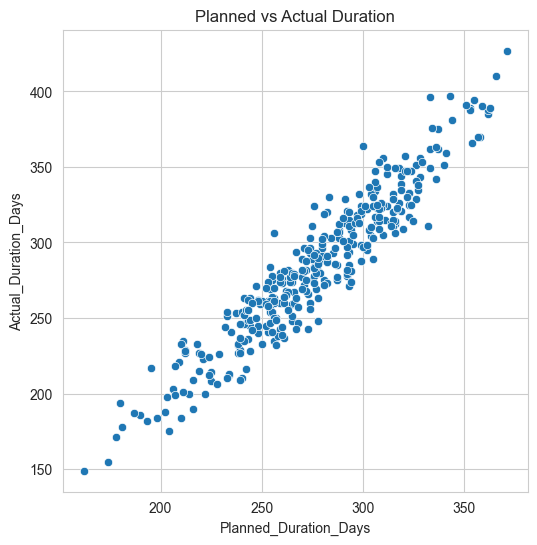

In [22]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x="Planned_Duration_Days",
    y="Actual_Duration_Days",
    data=project_df
)

plt.title("Planned vs Actual Duration")
plt.show()

**Key Insight**

- The scatter plot compares planned duration with actual duration for each project.
- While some projects remain close to plan, many deviate from the expected timeline, indicating that actual delivery is often less predictable than planned estimates suggest.
- This gap reinforces the need for forecasting approaches that go beyond static planning assumptions.

## Complexity vs Delay

Moving from single-variable analysis to relationship analysis:

This chart compares `Complexity_Score` across delayed and on-time projects.

The goal is to assess whether more complex projects tend to experience greater delivery problems.

This is relevant for feature selection because a strong relationship would suggest that complexity should be retained as an important predictor in later models.

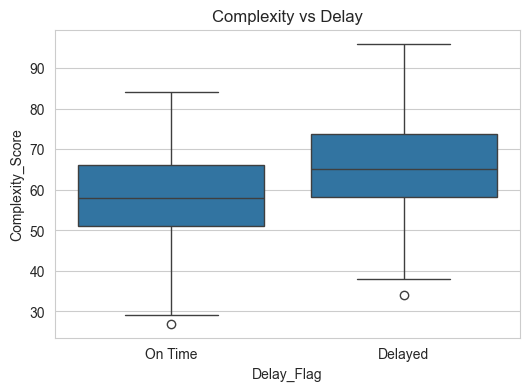

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Delay_Flag",
    y="Complexity_Score",
    data=project_df
)

plt.title("Complexity vs Delay")
plt.show()

**Key Insight**

- The chart compares project complexity scores between delayed and on-time projects.
- Delayed projects tend to show higher complexity levels than on-time projects.
- This suggests that project complexity is associated with schedule risk and may be an important explanatory feature in later modeling.

## Team Size vs Delay

Team size may influence project outcomes in different ways.

For example:

- larger teams may help absorb workload
- larger teams may also introduce coordination complexity

Comparing team size across delayed and on-time projects, can explore whether there is a visible relationship between staffing levels and delivery performance.

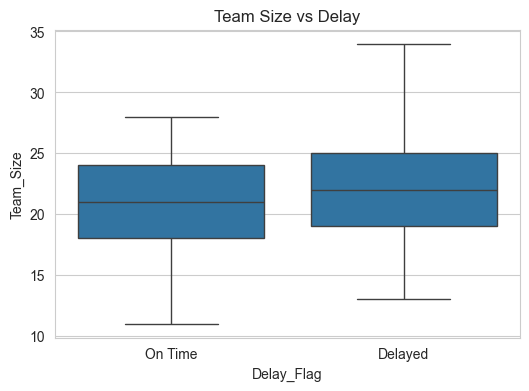

In [24]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Delay_Flag",
    y="Team_Size",
    data=project_df
)

plt.title("Team Size vs Delay")
plt.show()

**Key Insight**

- The chart compares team size between delayed and on-time projects.
- Differences between the groups suggest that team size may influence delivery outcomes, although the relationship is not as strong or direct as delay or complexity-based signals.
- This indicates that team size may still provide useful context when combined with other project features.

## Vendor Count vs Delay

External vendors can increase project complexity through:

- procurement dependencies
- communication overhead
- integration challenges

This section explores whether projects with more vendors tend to have worse schedule outcomes.

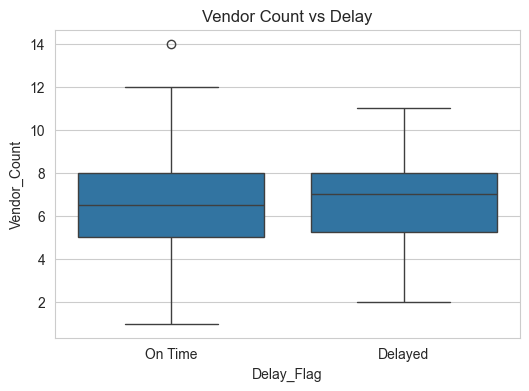

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Delay_Flag",
    y="Vendor_Count",
    data=project_df
)

plt.title("Vendor Count vs Delay")
plt.show()

**Key Insight**

- The chart compares vendor count between delayed and on-time projects.
- Projects involving more external vendors tend to show greater delay risk, likely due to increased coordination complexity and dependency management.
- This suggests that vendor involvement may contribute to operational uncertainty in project delivery.

## Budget Overrun Distribution

Since the business problem is not limited to schedule risk, I also examine cost performance.

The `Budget_Overrun_Pct` variable helps show:

- whether budget overruns are common
- how widely project cost performance varies

This is important because delays and cost overruns often occur together in real-world projects.

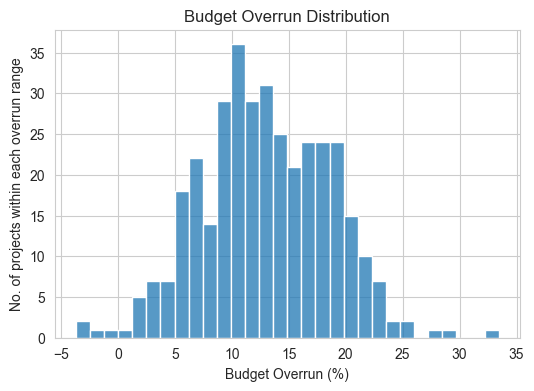

In [26]:
plt.figure(figsize=(6,4))

sns.histplot(
    project_df["Budget_Overrun_Pct"],
    bins=30
)

plt.title("Budget Overrun Distribution")
plt.xlabel("Budget Overrun (%)")
plt.ylabel("No. of projects within each overrun range")

plt.show()

**Key Insight**

- The chart shows the distribution of budget overruns across projects.
- Most projects appear within lower overrun ranges, while a smaller subset experiences substantially higher cost increases.
- This indicates that budget performance is uneven across the portfolio and may serve as an additional signal of project instability and risk.

## Correlation Analysis

After examining individual variables and selected pairwise relationships, a correlation matrix is calculated for the numerical features.

This helps identify:

- variables that move together
- potential predictors of delivery performance
- variables that may provide redundant information

Correlation does not imply causation, but it is useful for exploratory analysis and for informing feature engineering decisions.

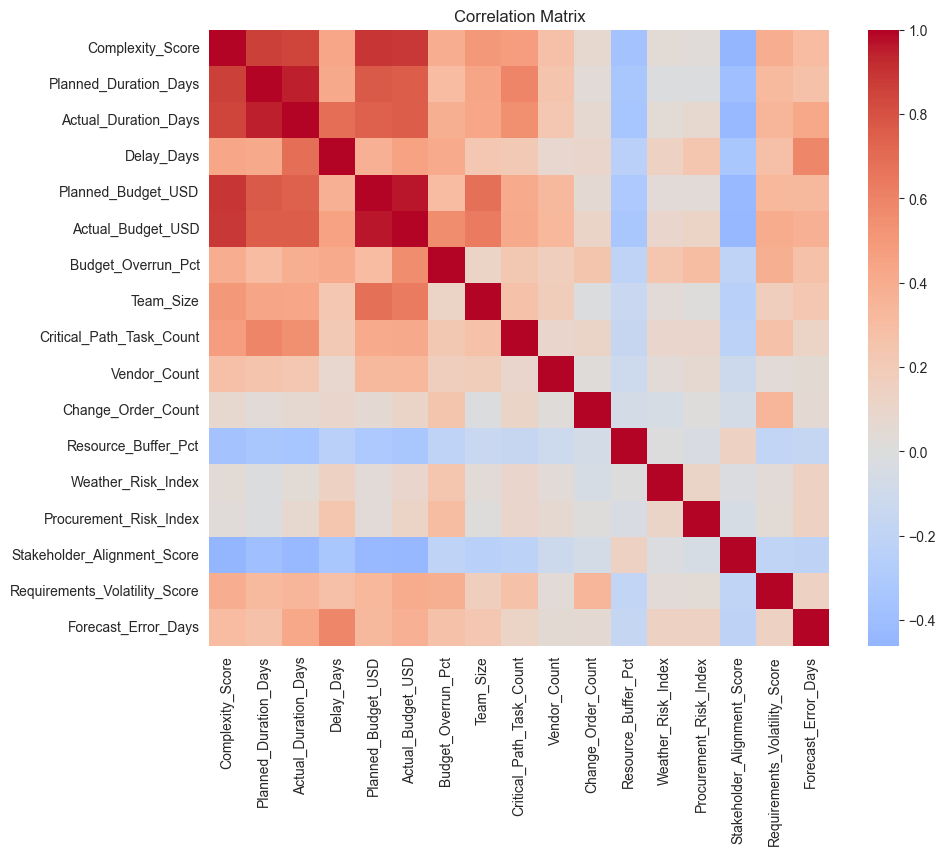

In [27]:
numeric_df = project_df.select_dtypes(include=["int64","float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

**Key Insight**

- The correlation matrix highlights the strength and direction of relationships between numerical project features.
- Delay, cost, and complexity-related variables show meaningful connections, supporting their relevance for downstream analysis.
- The heatmap provides an initial view of which features may contribute most strongly to forecasting and risk prediction.

## Key Insights & Takeaways

The exploratory analysis highlights several important patterns:

- Project delays are sufficiently common to justify a forecasting and risk analysis approach  
- Project complexity appears to be associated with delivery performance  
- Cost and schedule performance should be considered jointly rather than in isolation  
- Operational variables such as vendor count, team size, and requirements volatility may provide additional predictive signals  

Overall, the dataset shows strong potential for the next phases of the capstone:

- probabilistic forecasting (Monte Carlo simulation)  
- dependency-aware modeling (DAG)  
- predictive risk modeling  

The next notebook will focus on **model training and comparison** using the task-level dataset (`construction_dataset.csv`).